<a href="https://colab.research.google.com/github/tdineth/Neural-Network---Deep-Learning-CO5420-4th-sem/blob/main/lab01/wine_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas scikit-learn matplotlib graphviz pydotplus category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.8 MB/s eta 0:00:00


In [36]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [3]:
wine_df = pd.read_csv("/content/drive/MyDrive/Neural Network & Deep Learning - CO5420/lab 1/wine.csv")

In [5]:
wine_df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Check Dataset Shape

In [6]:
wine_df.shape

(178, 14)

## Check Column Names

In [9]:
wine_df.columns

Index(['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols',
       'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue',
       'OD', 'Proline'],
      dtype='object')

## Dataset Information

In [10]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


## Check Missing Values

In [11]:
wine_df.isnull().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


## Demonstrating Missing Value Handling

Even if no missing values exist, for the task to demonstrate handling.

We can intentionally create some missing values.

In [ ]:
wine_df_missing = wine_df.copy()

In [12]:
wine_df_missing.iloc[0, 1] = np.nan
wine_df_missing.iloc[5, 3] = np.nan
wine_df_missing.iloc[10, 5] = np.nan

In [13]:
wine_df_missing.isnull().sum()

,0
Wine,0
Alcohol,1
Malic.acid,0
Ash,1
Acl,0
Mg,1
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


## Handle Missing Values

We fill missing values using column mean.

In [18]:
wine_df_missing.mean()

,0
Wine,1.938202
Alcohol,12.993672
Malic.acid,2.336348
Ash,2.366045
Acl,19.494944
Mg,99.711864
Phenols,2.295112
Flavanoids,2.029270
Nonflavanoid.phenols,0.361854
Proanth,1.590899


In [19]:
wine_df_missing.fillna(wine_df_missing.mean(),inplace=True)

# With inplace=True → the original DataFrame is changed
# With inplace=False (default) → Pandas returns a new DataFrame, and you must assign it

In [21]:
wine_df_missing.isnull().sum()

,0
Wine,0
Alcohol,0
Malic.acid,0
Ash,0
Acl,0
Mg,0
Phenols,0
Flavanoids,0
Nonflavanoid.phenols,0
Proanth,0


## Define Features and Target

In [25]:
wine_df_missing["Wine"].nunique()

3

In [26]:
x = wine_df_missing.drop('Wine',axis=1)
y = wine_df_missing['Wine']

## Split Dataset

* 75% training
* 25% testing


In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=1
)



---



## Build Gini Decision Tree

In [28]:
clf_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=0
)

In [29]:
clf_gini.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=0)

## Predict Using Gini Tree

In [30]:
y_pred_gini = clf_gini.predict(x_test)

## Evaluate Gini Model

1. Accuracy



In [33]:
f"Gini Accuracy : {accuracy_score(y_test,y_pred_gini)}"

'Gini Accuracy : 0.9555555555555556'

2. Confusion Matrix

In [37]:
confussion_matrix = confusion_matrix(y_test,y_pred_gini)

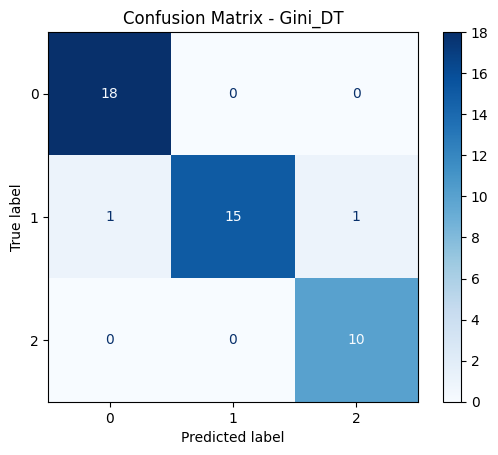

In [55]:
disp = ConfusionMatrixDisplay(confussion_matrix)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gini_DT")
plt.show()

3. Classification Report

In [60]:
report = classification_report(y_test, y_pred_gini, output_dict=True)
report_df_gini = pd.DataFrame(report).transpose()
report_df_gini

,precision,recall,f1-score,support
1,0.947368,1.000000,0.972973,18.000000
2,1.000000,0.882353,0.937500,17.000000
3,0.909091,1.000000,0.952381,10.000000
accuracy,0.955556,0.955556,0.955556,0.955556
macro avg,0.952153,0.960784,0.954285,45.000000
weighted avg,0.958745,0.955556,0.954996,45.000000




---



## Build Entropy Decision Tree

In [45]:
clf_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=0
)

In [46]:
clf_entropy.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)

## Predict Using Entropy Tree

In [48]:
y_pred_entropy = clf_entropy.predict(x_test)

## Evaluate Entropy Model

1. Accuracy

In [51]:
f"Entropy Accuracy: {accuracy_score(y_test, y_pred_entropy)}"

'Entropy Accuracy: 0.9555555555555556'

2. Confusion Matrix

In [52]:
confusion_matrix = confusion_matrix(y_test,y_pred_entropy)

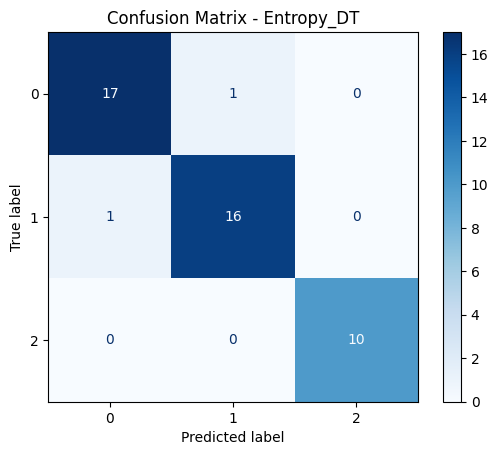

In [54]:
disp = ConfusionMatrixDisplay(confusion_matrix)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Entropy_DT")
plt.show()

3. Classification Report

In [59]:
report = classification_report(y_test, y_pred_entropy, output_dict=True)
report_df_entropy = pd.DataFrame(report).transpose()
report_df_entropy

,precision,recall,f1-score,support
1,0.944444,0.944444,0.944444,18.000000
2,0.941176,0.941176,0.941176,17.000000
3,1.000000,1.000000,1.000000,10.000000
accuracy,0.955556,0.955556,0.955556,0.955556
macro avg,0.961874,0.961874,0.961874,45.000000
weighted avg,0.955556,0.955556,0.955556,45.000000


## Comparing two models

**GINI METRICS**

In [ ]:
gini_accuracy = accuracy_score(y_test, y_pred_gini)
gini_precision = report_df_gini.loc['weighted avg', 'precision']
gini_recall = report_df_gini.loc['weighted avg', 'recall']
gini_f1 = report_df_gini.loc['weighted avg', 'f1-score']

**ENTROPY METRICS**

In [ ]:
entropy_accuracy = accuracy_score(y_test, y_pred_entropy)
entropy_precision = report_df_entropy.loc['weighted avg', 'precision']
entropy_recall = report_df_entropy.loc['weighted avg', 'recall']
entropy_f1 = report_df_entropy.loc['weighted avg', 'f1-score']

**CREATE COMPARISON TABLE**

In [65]:
comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score'
    ],

    'Gini': [
        gini_accuracy,
        gini_precision,
        gini_recall,
        gini_f1
    ],

    'Entropy': [
        entropy_accuracy,
        entropy_precision,
        entropy_recall,
        entropy_f1
    ]
})

**FIND BETTER MODEL**

In [69]:
comparison['Better'] = comparison.apply(
    lambda row:
    'Gini'
    if row['Gini'] > row['Entropy']
    else (
        'Entropy'
        if row['Entropy'] > row['Gini']
        else 'Equal'
    ),
    axis=1
)

In [70]:
comparison

,Metric,Gini,Entropy,Better
0,Accuracy,0.955556,0.955556,Equal
1,Precision,0.958745,0.955556,Gini
2,Recall,0.955556,0.955556,Equal
3,F1-Score,0.954996,0.955556,Entropy


## Pruning to Reduce Overfitting

**Deep Tree**

In [72]:
deep_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=0
)

deep_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=0)

**Pruned Tree**

In [73]:
pruned_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=0
)

pruned_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

**Compare Accuracy**

In [75]:
deep_pred = deep_tree.predict(x_test)
pruned_pred = pruned_tree.predict(x_test)

In [76]:
print("Deep Tree Accuracy:",
      accuracy_score(y_test, deep_pred))

print("Pruned Tree Accuracy:",
      accuracy_score(y_test, pruned_pred))

Deep Tree Accuracy: 0.9555555555555556
Pruned Tree Accuracy: 0.9555555555555556


## Visualize Decision Trees

**Visualize Gini Tree**

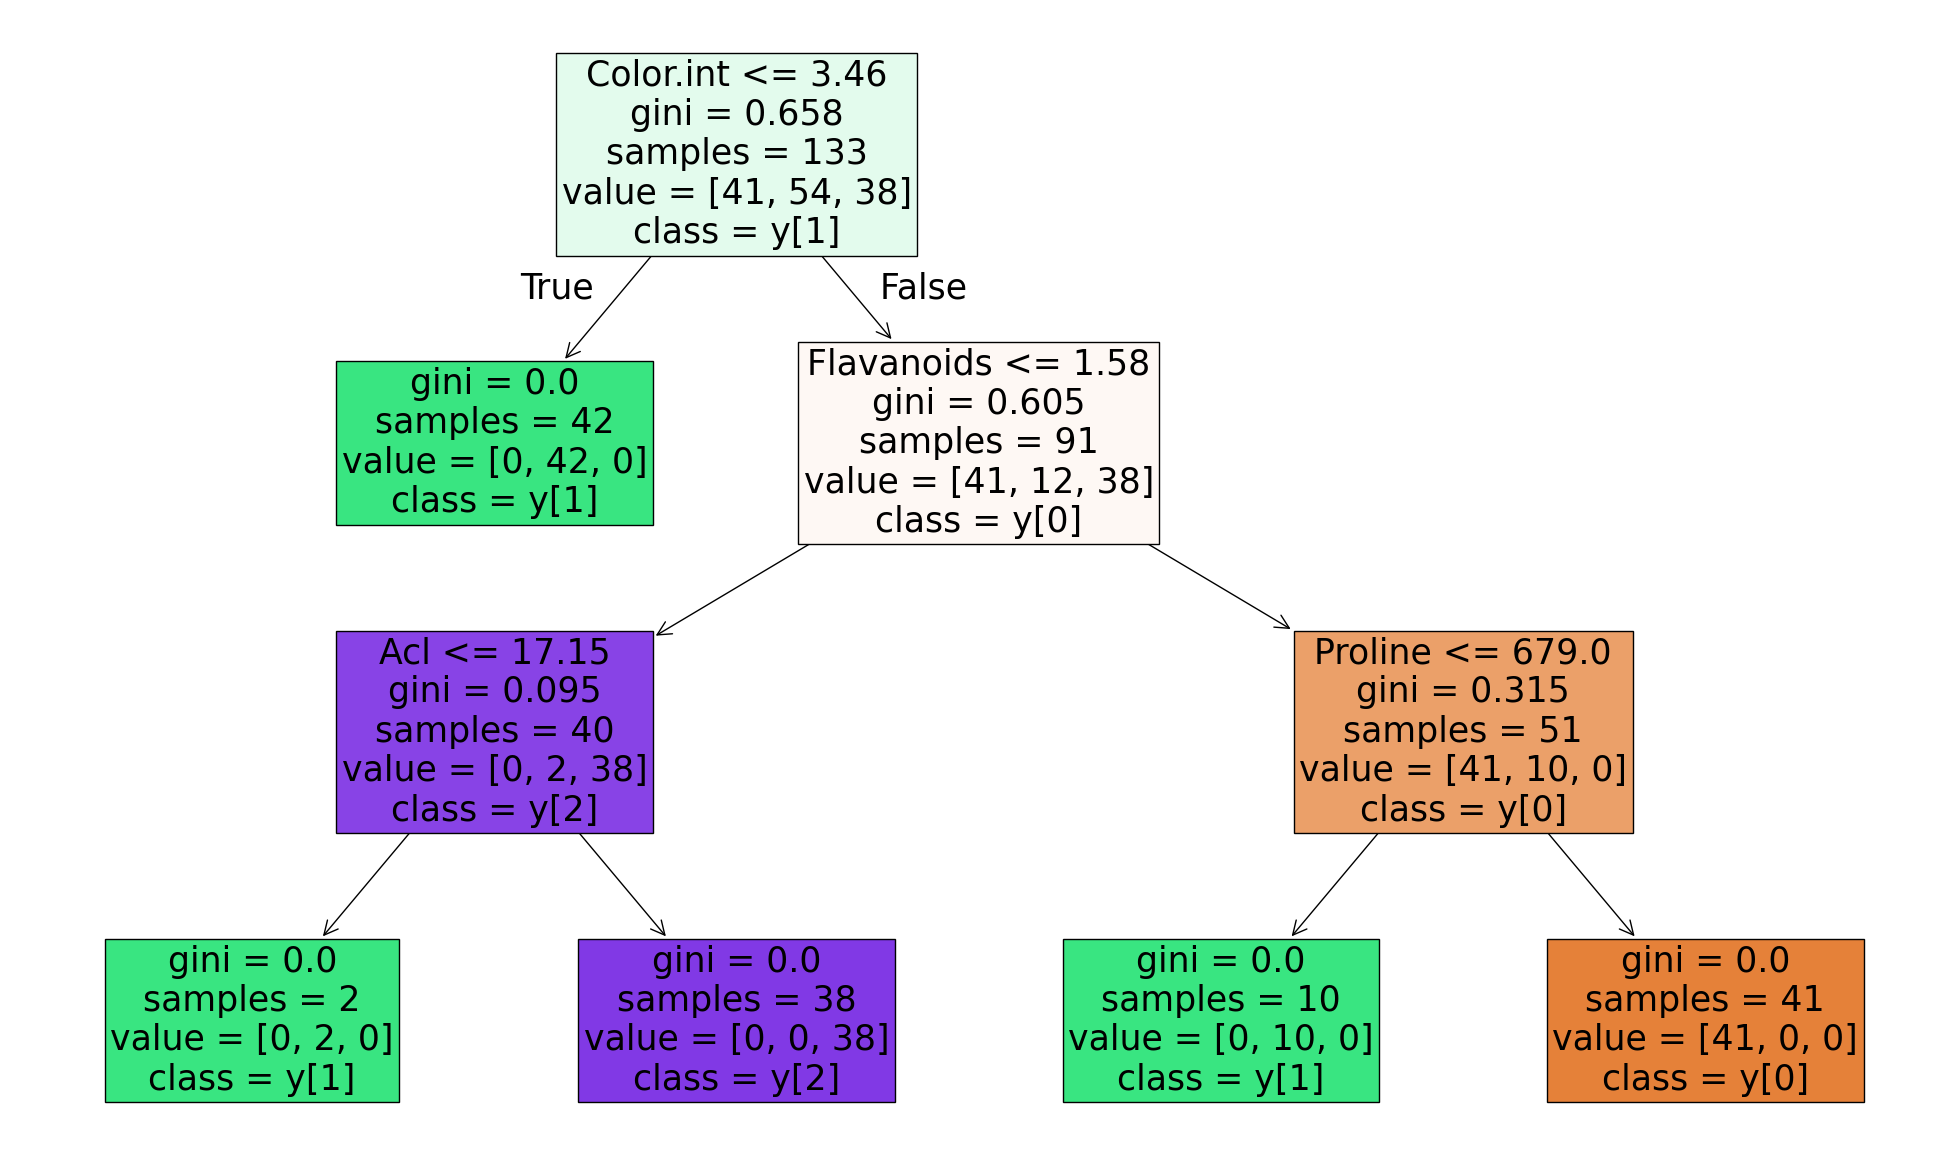

In [91]:
plt.figure(figsize=(25, 15))
plot_tree(clf_gini, filled=True, feature_names=x.columns, class_names=True,fontsize=25)
plt.show()


**Visualize Entropy Tree**

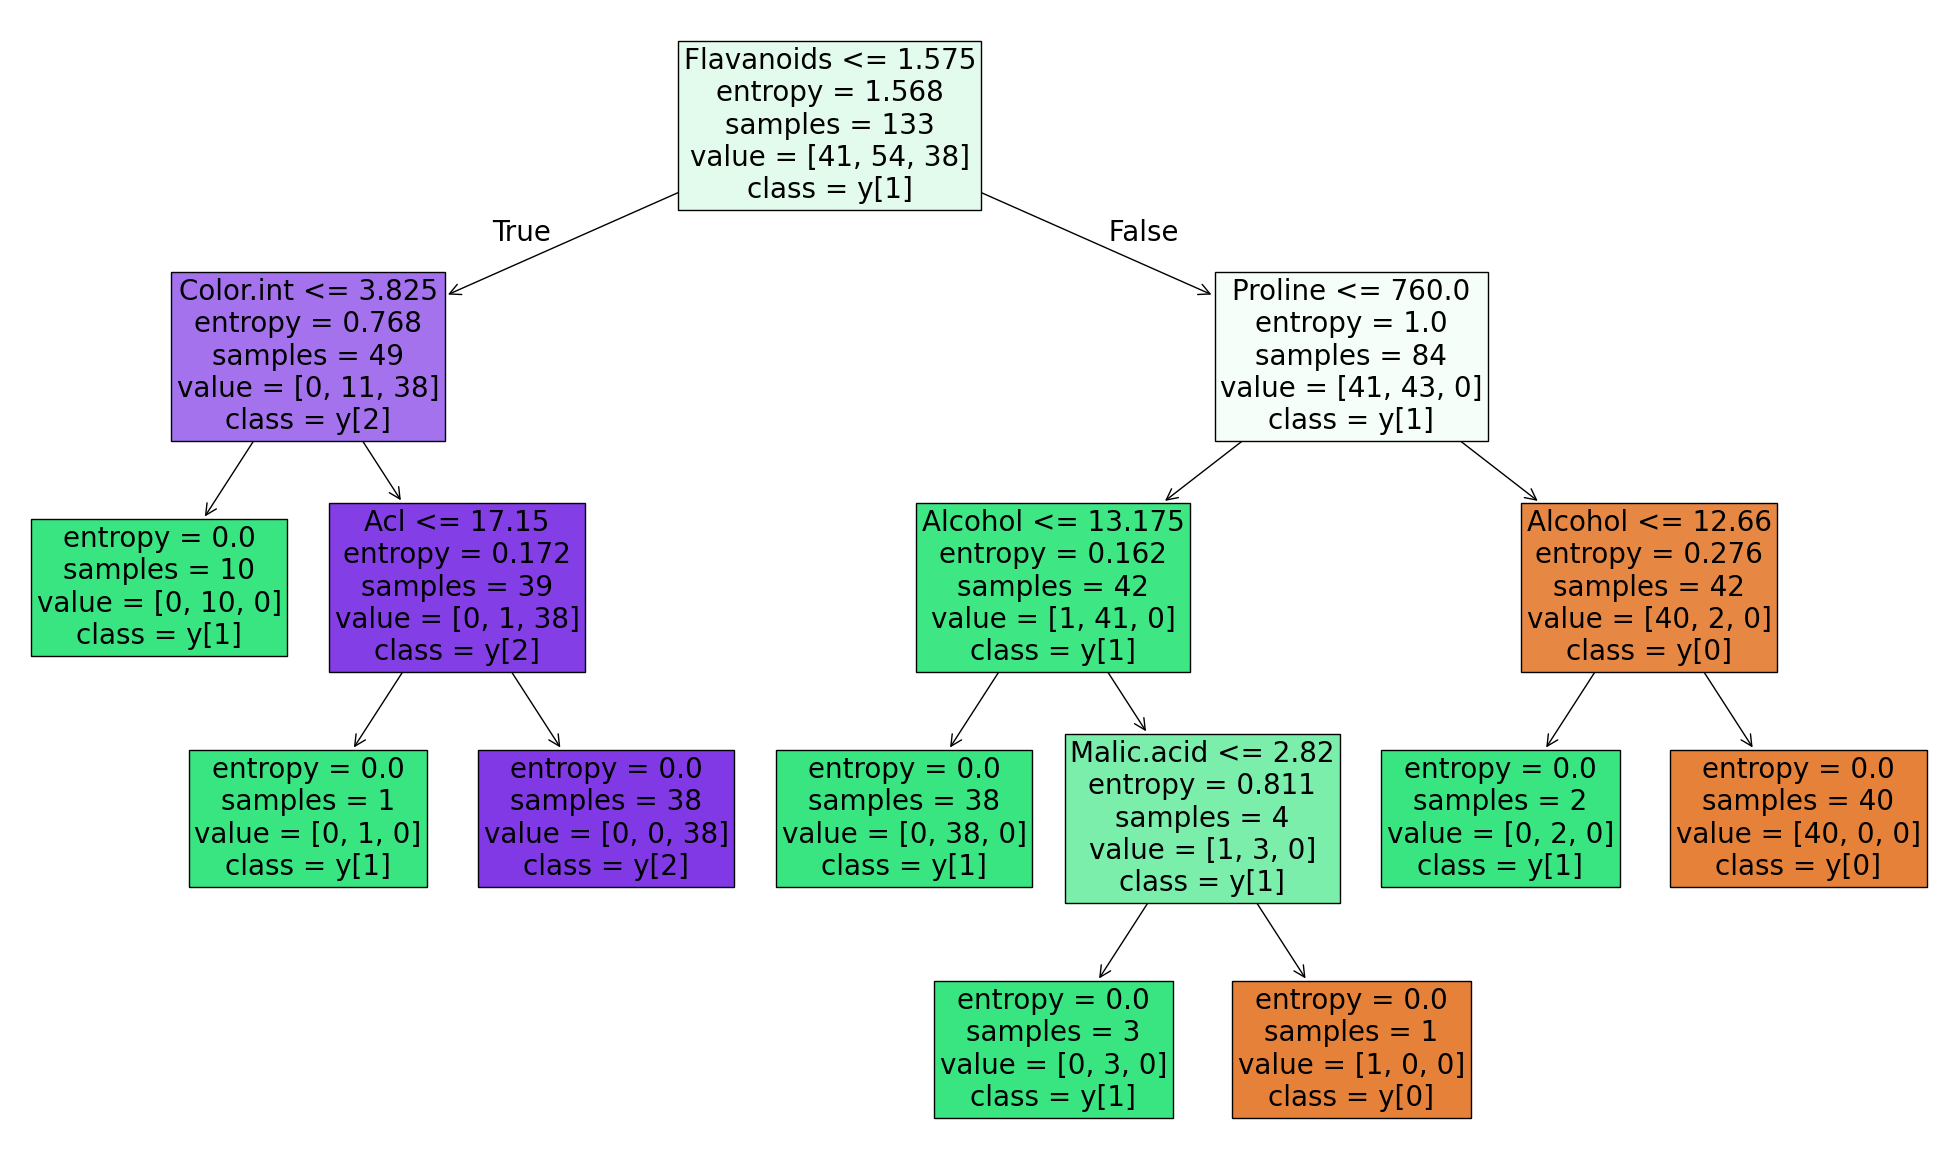

In [93]:
plt.figure(figsize=(25, 15))
plot_tree(clf_entropy, filled=True, feature_names=x.columns, class_names=True,fontsize=20)
plt.show()